In [8]:
%pip install xmltodict

  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
Using cached xmltodict-1.0.4-py3-none-any.whl (13 kB)
Note: you may need to restart the kernel to use updated packages.


In [131]:
import numpy as np
import pandas as pd
# 데이터 요청 및 처리
import requests
import json
# 키 숨김처리
import os
from dotenv import load_dotenv
# XML을 딕셔너리로 바꿔주는 라이브러리
import xmltodict
# 시각화 세트
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [56]:
load_dotenv()
# 1. API 설정
serviceKey = os.getenv('DATA_GO_KR_API_KEY')
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"
params = {
    'serviceKey':serviceKey,
    'pageNo':'1',
    'numOfRows':'100',
    # 'zcode':'',
    # 'zscode':'',
    # 'kind':'',
    # 'kindDetail':'',
    # 'statId':'',
    # 'chgerId':'',
    'dataType':'XML',    
}
# 2. API 호출 및 JSON 파싱
response = requests.get(url, params=params)
dict_data = xmltodict.parse(response.content)
data_list = dict_data['response']['body']['items']['item']
# 3. DataFrame으로 변환
df_all = pd.DataFrame(data_list)
df_all.to_csv('EvCharger.csv', encoding='utf-8-sig', index=False)
df_all.head()

,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,null,null,37.476296,126.9583876,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,null,37.4536062,127.0428005,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,null,37.4918392,127.1178931,24시간 이용가능,...,None,N,None,N,None,N,2017,4,B,시그넷
3,현대자동차 수색대리점,ME174037,01,06,서울특별시 은평구 수색로 342-1,null,null,37.5867665,126.8880299,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
4,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,null,37.5718148,126.9850443,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷


In [57]:
df_all.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

1. 수집된 데이터의 shape과 실제 데이터 출력

In [60]:
df_all.shape

(100, 37)

In [62]:
df_all

,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,null,null,37.476296,126.9583876,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,null,37.4536062,127.0428005,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,null,37.4918392,127.1178931,24시간 이용가능,...,None,N,None,N,None,N,2017,4,B,시그넷
3,현대자동차 수색대리점,ME174037,01,06,서울특별시 은평구 수색로 342-1,null,null,37.5867665,126.8880299,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
4,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,null,37.5718148,126.9850443,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,충주(창원) 휴게소,ME178069,01,06,충청북도 충주시 중앙탑면 중부내륙고속도로 231 (용전리),null,null,37.0219027,127.8379417,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,채비
96,충주(양평) 휴게소,ME178070,01,06,충청북도 충주시 중앙탑면 중부내륙고속도로 230 (용전리),null,null,37.0235629,127.8390638,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,채비
97,동명(춘천) 휴게소,ME178072,01,06,경상북도 칠곡군 동명면 중앙고속도로 122 (가천리),null,null,36.0068197,128.5488571,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,채비
98,원주(부산) 휴게소,ME178073,01,06,강원특별자치도 원주시 호저면 마근거리길 120 (옥산리) 211,null,null,37.4345781,127.9292055,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,채비


2. 분석에 필요한 핵심 컬럼만 선택

In [66]:
# statNm: 충전소명, addr: 주소, chgerType: 충전기 타입, useTime: 이용시간
column_map = {
    'statNm': '충전소명',
    'addr': '주소',
    'chgerType': '충전기 타입',
    'useTime': '이용시간'    
}
df_all = pd.read_csv('EvCharger.csv')
df = df_all[['statNm','addr','chgerType','useTime']]
display(df.rename(columns=column_map).head())

,충전소명,주소,충전기 타입,이용시간
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능


3. 결측치(NaN) 확인 및 처리

In [68]:
df.isnull().sum()

statNm       0
addr         0
chgerType    0
useTime      0
dtype: int64

4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)

In [75]:
# 1. 중복 확인
# 'keep=False'로 설정하면 중복된 모든 행(원본+복사본 전체)을 보여줍니다.
duplicate_rows = df[df.duplicated(subset=['statNm', 'addr'], keep=False)]

# 결과 확인 (정렬해서 보면 중복 데이터끼리 모여서 보기 편합니다)
display(duplicate_rows.sort_values(by=['statNm', 'addr']))

,statNm,addr,chgerType,useTime
64,고창고인돌(목포) 휴게소,전북특별자치도 고창군 고창읍 서해안고속도로 81 (벽송리),6,24시간 이용가능
65,고창고인돌(목포) 휴게소,전북특별자치도 고창군 고창읍 서해안고속도로 81 (벽송리),6,24시간 이용가능
90,괴산(양평) 휴게소,충청북도 괴산군 장연면 중부내륙고속도로 204 (오가리),6,24시간 이용가능
91,괴산(양평) 휴게소,충청북도 괴산군 장연면 중부내륙고속도로 204 (오가리),6,24시간 이용가능
47,금강(부산) 휴게소,충청북도 옥천군 동이면 금강로 596 (조령리),6,24시간 이용가능
48,금강(부산) 휴게소,충청북도 옥천군 동이면 금강로 596 (조령리),6,24시간 이용가능
49,금강(부산) 휴게소,충청북도 옥천군 동이면 금강로 596 (조령리),6,24시간 이용가능
29,기흥(부산) 휴게소,경기도 용인시 기흥구 공세로 173 (공세동),6,24시간 이용가능
30,기흥(부산) 휴게소,경기도 용인시 기흥구 공세로 173 (공세동),6,24시간 이용가능
31,김천(부산) 휴게소,경상북도 김천시 농소면 경부고속도로 193 (신촌리),6,24시간 이용가능


In [81]:
# 2. 중복 제거
# 방법 1: 충전소 이름과 주소가 모두 같아야 '진짜 같은 곳'으로 판정
df_unique = df.drop_duplicates(subset=['statNm', 'addr'], keep='first').copy()
df_unique.head()
# 방법 2: 가장 정확한 방법 (이름 + 위도 + 경도)
# 휴게소 상/하행은 위도(lat), 경도(lng)가 반드시 다르기 때문에 살아남습니다.
# df_unique = df.drop_duplicates(subset=['statNm', 'lat', 'lng'], keep='first')

,statNm,addr,chgerType,useTime
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능


## 특성공학
1. 주소 데이터에서 '시/도' 파생 변수 생성

In [83]:
# 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출
df_unique['sido'] = df_unique['addr'].str.split().str[0]
df_unique.head()

,statNm,addr,chgerType,useTime,sido
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울특별시
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울특별시
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울특별시
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울특별시
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울특별시


In [87]:
# 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일
df_unique['sido'] = df_unique['sido'].str[:2]
df_unique.head(3)

,statNm,addr,chgerType,useTime,sido
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울


2. 충전기 타입 범주화 (Mapping)

In [100]:
df_unique.shape

(69, 5)

In [108]:
# 빈도수 확인 (내림차순 정렬됨)
df_unique['chgerType'].value_counts()

chgerType
6    69
Name: count, dtype: int64

In [114]:
# API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) 
# : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타
# API 코드값을 텍스트로 치환
type_map = {1: '완속', 3: '급속', 6: '초급속'}
df_unique['type_nm'] = df_unique['chgerType'].map(type_map).fillna('기타')
df_unique.head()

,statNm,addr,chgerType,useTime,sido,type_nm
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울,초급속
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울,초급속
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울,초급속
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울,초급속
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울,초급속


3. 24시간 이용 가능 여부 파생 변수 생성

In [116]:
# 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환
# '24시간' 글자가 포함되어 있으면 True
df_unique['is_24h'] = df_unique['useTime'].str.contains('24시간')
df_unique.head()

,statNm,addr,chgerType,useTime,sido,type_nm,is_24h
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울,초급속,True
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울,초급속,True
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울,초급속,True
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울,초급속,True
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울,초급속,True


In [118]:
# 빈도수 확인 (내림차순 정렬됨)
df_unique['is_24h'].value_counts()

is_24h
True     67
False     2
Name: count, dtype: int64

In [120]:
df_unique.to_csv('EvCharger_Preprocessing.csv', encoding='utf-8-sig', index=False)

## 📊 시각화
- 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)
- 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)
- 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

In [125]:
# 빈도수 확인 (내림차순 정렬됨)
df_unique['sido'].value_counts()

sido
충청    20
경상    12
경기     8
제주     7
서울     6
인천     5
전북     5
대전     3
전라     2
강원     1
Name: count, dtype: int64

<Axes: xlabel='sido', ylabel='count'>

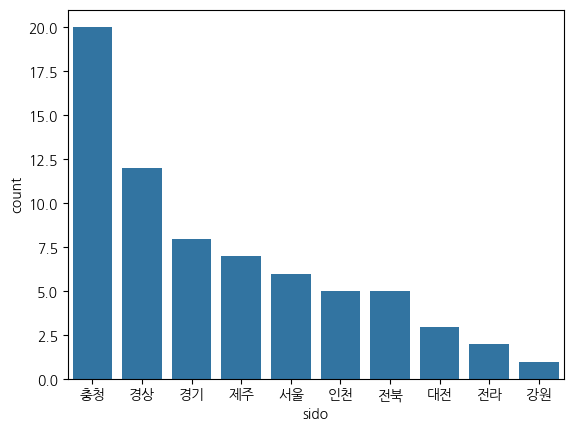

In [133]:
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)
sns.countplot(data=df_unique, x='sido', order=df_unique['sido'].value_counts().index)

<Axes: ylabel='count'>

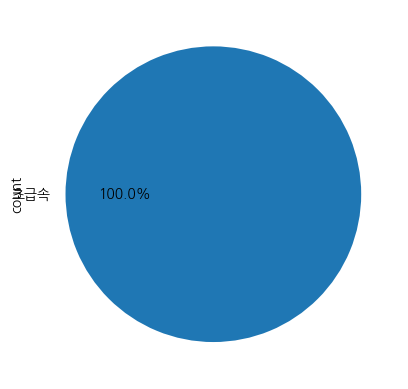

In [135]:
# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)
df_unique['type_nm'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: xlabel='sido', ylabel='count'>

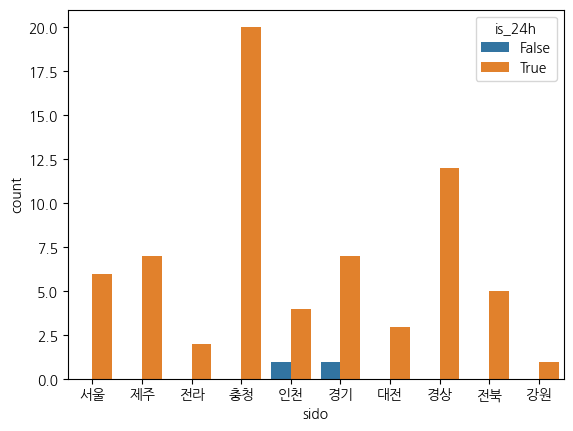

In [139]:
# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)
# Countplot hue 사용
sns.countplot(data=df_unique, x='sido', hue='is_24h')

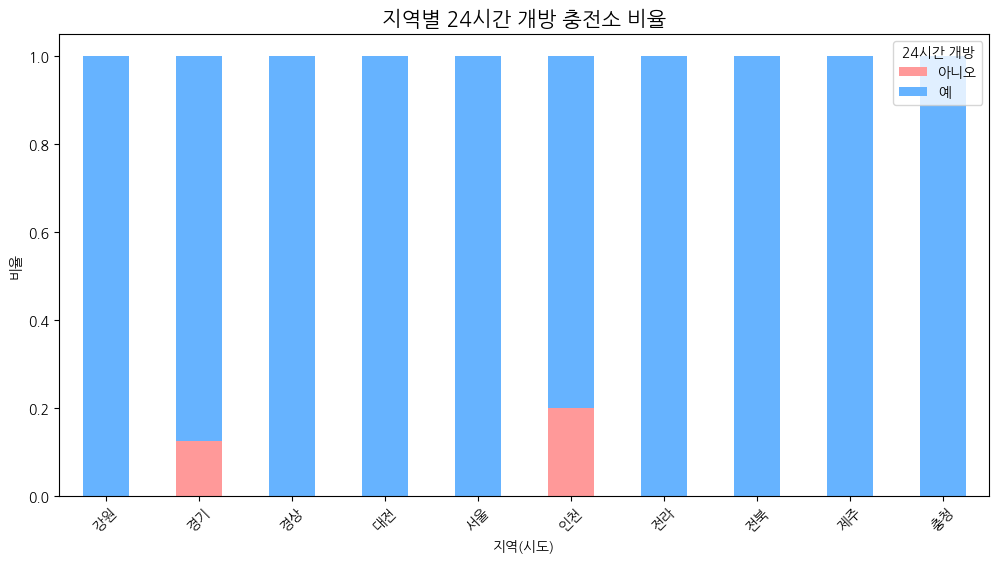

In [141]:
# Stacked Bar Chart 사용
# 1. 시도별 24시간 여부 교차표 생성
ct = pd.crosstab(df_unique['sido'], df_unique['is_24h'])

# 2. 비율로 변환 (각 행의 합으로 나눔) -> 0~1 사이 값
ct_pct = ct.div(ct.sum(1), axis=0)

# 3. 시각화
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff'])

plt.title('지역별 24시간 개방 충전소 비율', fontsize=15)
plt.xlabel('지역(시도)')
plt.ylabel('비율')
plt.legend(title='24시간 개방', labels=['아니오', '예'], loc='upper right')
plt.xticks(rotation=45)
plt.show()

In [149]:
df_unique['is_24h'].value_counts()

is_24h
True     67
False     2
Name: count, dtype: int64

<Axes: >

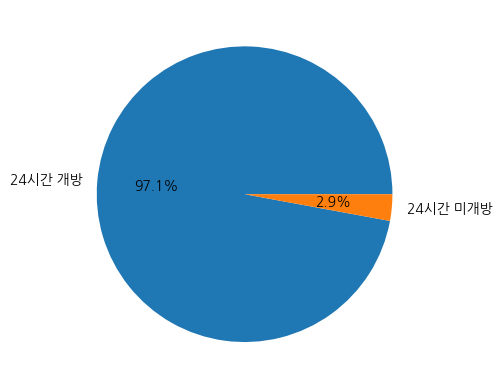

In [175]:
# 비율 확인
df_unique['is_24h'].value_counts().rename({True: '24시간 개방', False: '24시간 미개방'}).plot.pie(autopct='%1.1f%%', ylabel='')

## 도출 인사이트

In [ ]:
인프라 집중도 : 현재 데이터상으로만 보면 충청, 경상도의 인프라 집중도가 좋은편
기술 트랜드 : 초급속 보급률이 100%로 트랜드 반영을 매우 잘되고 있음
편의성 : 24시간개방이 97%이상으로 매우 편의성이 좋은것으로 보임